# Annotation Quality Evaluation

Analyses the quality of the LLM-produced annotation stored in
`annotation/eval_annotated.parquet`.

The annotation produces:
1. `caregiver_clear` and `caregiver_vague`
2. `time_of_day`
3. `event_time`
4. `schedule`

In this notebook we will inspect their formal and semantic correctness and correct the annotation if necessary.

## 1. Setup

In [1]:
import sys
import re
import json
import ast
import math
import random
from collections import Counter
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

import nltk
nltk.download('wordnet',  quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4',  quiet=True)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

NOTEBOOK_DIR = Path().resolve()
# notebook lives at annotation/ or at project root depending on how it is run
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'annotation').is_dir() else NOTEBOOK_DIR.parent
ANN_DIR = ROOT / 'annotation'

print(f'ROOT    : {ROOT}')
print(f'ANN_DIR : {ANN_DIR}')

ROOT    : /Users/pelle/Development/GitHub/aac-mcp-agent
ANN_DIR : /Users/pelle/Development/GitHub/aac-mcp-agent/annotation


## 2. Dataset load

In [2]:
ANNOTATED_PATH  = ANN_DIR / 'eval_annotated.parquet'
FILTERED_PATH   = ANN_DIR / 'eval_filtered.parquet'
LOG_PATH        = ANN_DIR / 'annotation_log.jsonl'

df_ann = pd.read_parquet(ANNOTATED_PATH)
df_flt = pd.read_parquet(FILTERED_PATH)

print(f'Annotated  : {len(df_ann):,} rows  cols={list(df_ann.columns)}')
print(f'Filtered   : {len(df_flt):,} rows  cols={list(df_flt.columns)}')
df_ann.head(3)

Annotated  : 1,760 rows  cols=['sentence', 'concepts', 'caregiver_clear', 'caregiver_vague', 'time_of_day', 'event_time', 'schedule', 'tod_selection', 'split']
Filtered   : 1,760 rows  cols=['sentence', 'concepts']


,sentence,concepts,caregiver_clear,caregiver_vague,time_of_day,event_time,schedule,tod_selection,split
0,The blue train is going fast.,"[{'candidate_ids': [2603, 29010, 7282, 10187, ...",He is playing with the blue train at 06:15 thi...,he keeps asking for the blue one,morning,06:15,[],model,both
1,The music is too loud in here.,"[{'candidate_ids': [9851, 23811, 37486, 38106,...",He is annoyed by the loud music at 20:15 this ...,he keeps covering his ears,evening,20:15,"[{'title': 'Family gathering', 'start_time': '...",model,both
2,Look at the bubbles popping.,"[{'candidate_ids': [9851, 17054, 6155, 30510, ...",He is enjoying the bubbles at 17:15 this after...,he keeps reaching for more bubbles,afternoon,17:15,"[{'title': 'Playtime with bubbles', 'start_tim...",model,both


## 3. Data cleaning

### 3.1 Null values

In [3]:
df_ann.info()

<class 'pandas.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sentence         1760 non-null   str   
 1   concepts         1760 non-null   object
 2   caregiver_clear  1760 non-null   str   
 3   caregiver_vague  1760 non-null   str   
 4   time_of_day      1760 non-null   str   
 5   event_time       1760 non-null   str   
 6   schedule         1760 non-null   object
 7   tod_selection    1760 non-null   str   
 8   split            1760 non-null   str   
dtypes: object(2), str(7)
memory usage: 372.6+ KB


In [4]:
df_ann[df_ann.isnull().any(axis=1)]

,sentence,concepts,caregiver_clear,caregiver_vague,time_of_day,event_time,schedule,tod_selection,split


In [5]:
before = len(df_ann)
df_ann.dropna(inplace=True)
print(f'Dropped {before - len(df_ann)} rows, the remaining are {len(df_ann)} rows.')

Dropped 0 rows, the remaining are 1760 rows.


There are no nulls but i keep this step as it has been very useful in previous trials. I will do this with also other following steps. This imporvement follows the change from Qwen-3B to Qwen-7B which has produced more accurate annotations.

### 3.2 Empty str values

In [6]:
# Check all the new rows except for "schedule"
text_cols = ['caregiver_clear', 'caregiver_vague', 'time_of_day', 'event_time', 'tod_selection', 'split']
empty_mask = df_ann[text_cols].apply(lambda col: col.astype(str).str.strip() == '')
empty_rows = df_ann[empty_mask.any(axis=1)]
print(f"Rows with empty srings: {len(empty_rows)}")

Rows with empty srings: 0


### 3.3 Ensure that there is no `{TIME}` left unreplaced

In [7]:
critical_cols = df_ann.columns[2:].tolist()
mask_time = df_ann[critical_cols].apply(lambda s: s.astype(str).str.contains("{TIME}", regex=False)).any(axis=1)
rows_with_time = df_ann[mask_time]
wrongs = []
for c in rows_with_time.columns:
    for i in rows_with_time.index:
        if "{TIME}" in str(rows_with_time.loc[i, c]):
            print(f"row {i} in col {c}: {rows_with_time.loc[i, c]}")
            wrongs.append(i)

### 3.4 Ensure that the inputs are in correct ASCII

In [8]:
# Check for non-ASCII characters in text columns
interest_cols = ["caregiver_clear", "caregiver_vague", "time_of_day", "event_time", "schedule"]
IS_ASCII = r'[^\x00-\x7F]'
for col in interest_cols:
    bad = df_ann[df_ann[col].apply(lambda v: bool(re.search(IS_ASCII, str(v))))]
    if len(bad):
        print(f"{col}: {len(bad)} rows with non-ASCII")
        for i, r in bad.iterrows():
            print(f"\tidx={i})  {r[col]}")
            wrongs.append(i)
    else:
        print(f"{col}: OK")

caregiver_clear: OK
caregiver_vague: 2 rows with non-ASCII
	idx=969)  she is专注 here
	idx=1489)  he keeps asking about tomorrow’s topic
time_of_day: OK
event_time: OK
schedule: OK


In [9]:
# Look at the rows to handle them manually correctly 
df_ann.loc[wrongs, :]

,sentence,concepts,caregiver_clear,caregiver_vague,time_of_day,event_time,schedule,tod_selection,split
969,I want to finish this coloring page.,"[{'candidate_ids': [9851, 6955, 5946, 25133, 1...",She wants to finish her coloring page at 16:00...,she is专注 here,afternoon,16:00,[],model,both
1489,This lesson is very helpful for my career goals.,"[{'candidate_ids': [9851, 38170, 37810, 28717,...",He is having a helpful lesson at 14:45 this af...,he keeps asking about tomorrow’s topic,afternoon,14:45,"[{'title': 'Career development lesson', 'start...",model,both


Since i know they are very few and specific i just correct them manually.

In [10]:
df_ann.loc[wrongs[0], "caregiver_vague"] = "she is focused here"    # i translated it
df_ann.loc[wrongs[1], "caregiver_vague"] = "he keeps asking about tomorrow\'s topic"

### 3.5 Ensure that both the splits are annotated.

In [11]:
df_ann["split"].value_counts()

split
both    1760
Name: count, dtype: int64

### 3.6 Ensure that the generated `time_of_day` is coherent with other generated fields.

In [12]:
TODS   = ["morning", "afternoon", "evening", "night"]
FIELDS = ["caregiver_clear", "caregiver_vague", "schedule"]

# Extract conflicts using a nested list comprehension
conflicts = [
    {"index": i, "expected": str(row["time_of_day"]).lower(), "conflict": t, "field": f, "content": row[f]}
    for i, row in df_ann.iterrows()
    for f in FIELDS
    for t in TODS if t in str(row[f]).lower() and t != str(row["time_of_day"]).lower()
]

df_conflicts = pd.DataFrame(conflicts)
print(f"Conflicts found: {len(df_conflicts)}" if not df_conflicts.empty else "No conflicts.")
display(df_conflicts)

Conflicts found: 30


,index,expected,conflict,field,content
0,116,morning,afternoon,caregiver_clear,He needs to go to the bathroom at 05:30 this a...
1,170,evening,night,schedule,"[{'title': 'Bedtime routine', 'start_time': '1..."
2,172,afternoon,morning,caregiver_vague,he kept asking about it all morning
3,175,afternoon,morning,caregiver_vague,he kept asking about it all morning
4,227,morning,afternoon,caregiver_clear,He needs to go to the bathroom at 05:30 this a...
5,234,evening,night,schedule,"[{'title': 'Bedtime routine', 'start_time': '1..."
6,343,evening,night,schedule,"[{'title': 'Movie night', 'start_time': '18:15..."
7,480,evening,night,schedule,"[{'title': 'Nightly check-up', 'start_time': '..."
8,507,evening,night,caregiver_vague,it's Friday night already
9,551,evening,night,caregiver_clear,He wants to watch the Cubs game at 18:00 tonight


They are all real mistakes

In [13]:
df_conflicts["field"].value_counts()

field
schedule           17
caregiver_clear     9
caregiver_vague     4
Name: count, dtype: int64

In [14]:
import ast

# The solution is maybe too much specific but i always found the same problems here
SPECIAL_FORMS = {
    "night":   {"tonight": "this {e}", "nightly": "{e}ly", "last night": "last {e}"},
    "morning": {"this morning": "this {e}"},
    "afternoon": {"this afternoon": "this {e}"},
    "evening": {"this evening": "this {e}"},
}

def fix_tod(text, expected, conflict):
    if not isinstance(text, str):
        return text
    forms = {**SPECIAL_FORMS.get(conflict, {}), conflict: expected}
    for wrong, tmpl in forms.items():
        repl = tmpl.format(e=expected) if "{e}" in tmpl else tmpl
        text = re.sub(
            rf'\b{re.escape(wrong)}\b',
            lambda m, r=repl: r.capitalize() if m.group(0)[0].isupper() else r,
            text, flags=re.IGNORECASE
        )
    return text

def global_tod_fixer(row):
    expected = str(row["time_of_day"]).lower()

    for field in FIELDS:
        val = row[field]
        if val is None:
            continue

        for conflict in [t for t in TODS if t != expected]:
            # str() only for the membership check, never mutates the value
            if conflict not in str(val).lower():
                continue

            fix = lambda t, e=expected, c=conflict: fix_tod(t, e, c)

            match field:
                case "caregiver_clear" | "caregiver_vague":
                    row[field] = fix(row[field])
                case "schedule":
                    # schedule is guaranteed to be list[dict] after normalisation
                    for entry in row[field]:
                        entry.update({k: fix(v) for k, v in entry.items() if isinstance(v, str)})
                    # no str() — keep it as list

    return row

In [15]:
# Apply to the whole dataset
df_ann = df_ann.apply(global_tod_fixer, axis=1)

### 3.7 In which way the timeofday is expressed?

In [16]:
df_ann["tod_selection"].value_counts()

tod_selection
model      1728
keyword      23
random        9
Name: count, dtype: int64

### 3.8 Ensure that `time_of_day` and `event_time` are consistent with each other.

In [17]:
event_times_parsed = pd.to_datetime(df_ann['event_time'], format='%H:%M', errors='coerce').dt.time
time_of_day_dict = event_times_parsed.groupby(df_ann['time_of_day']).apply(list).to_dict()

for tod, times in time_of_day_dict.items():
    unique_times = sorted(list(set(times)))
    formatted_times = [t.strftime('%H:%M') for t in unique_times]
    print(f"{tod}: da {formatted_times}")

afternoon: da ['13:00', '13:15', '13:30', '13:45', '14:00', '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45', '16:00', '16:15', '16:30', '16:45', '17:00', '17:15', '17:30', '17:45']
evening: da ['18:00', '18:15', '18:30', '18:45', '19:00', '19:15', '19:30', '19:45', '20:00', '20:15', '20:30', '20:45']
morning: da ['05:00', '05:15', '05:30', '05:45', '06:00', '06:15', '06:30', '06:45', '07:00', '07:15', '07:30', '07:45', '08:00', '08:15', '08:30', '08:45', '09:00', '09:15', '09:30', '09:45', '10:00', '10:15', '10:30', '10:45', '11:00', '11:15', '11:30', '11:45', '12:00', '12:15', '12:30', '12:45']
night: da ['00:00', '00:15', '00:30', '00:45', '01:00', '01:15', '01:30', '01:45', '02:00', '02:15', '02:30', '02:45', '03:15', '03:30', '03:45', '04:15', '04:30', '21:00', '21:15', '21:30', '21:45', '22:00', '22:15', '22:30', '22:45', '23:00', '23:15', '23:30', '23:45']


# 4. Data analysis

### 4.1 Length distribution of both the generated inputs

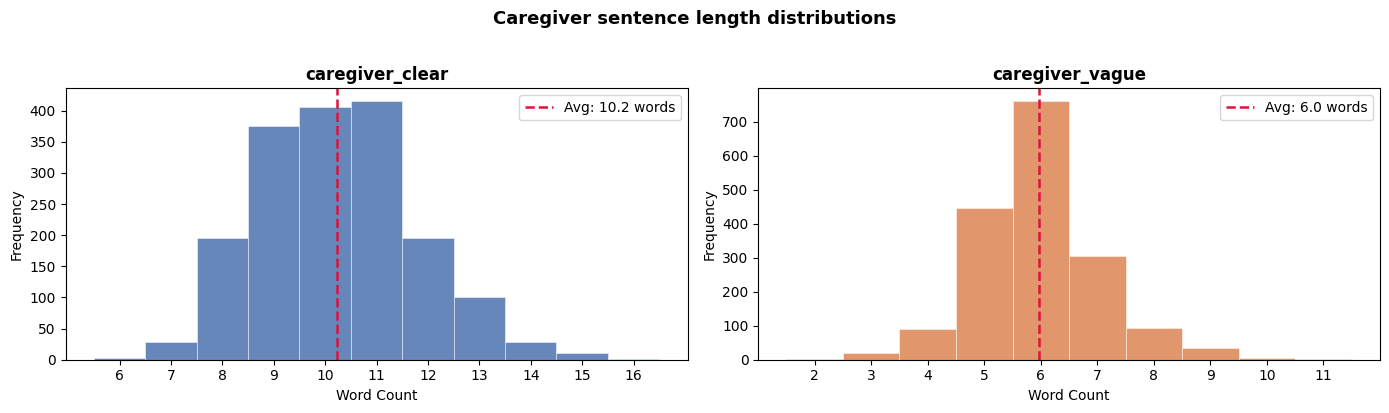

In [18]:
COLORS = {'clear': '#4C72B0', 'vague': '#DD8452'}
_df = df_ann.copy()

_df['len_clear'] = _df['caregiver_clear'].str.split().str.len()
_df['len_vague']  = _df['caregiver_vague'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
configs = [
    (axes[0], 'len_clear', 'caregiver_clear', COLORS['clear']),
    (axes[1], 'len_vague', 'caregiver_vague', COLORS['vague'])
]

for ax, col, label, color in configs:
    vals = _df[col].dropna()
    start, end = int(vals.min()), int(vals.max())
    bins = [t - 0.5 for t in range(start, end + 2)]  # to center bin xtick
    ax.hist(vals, bins=bins, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    avg = vals.mean()
    ax.axvline(avg, color='crimson', lw=1.8, ls='--', label=f'Avg: {avg:.1f} words')
    ax.set_xticks(range(start, end + 1, 1))
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Caregiver sentence length distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This follows the request in the prompt.

### 4.2 The distribution of the generated `time_of_day`.

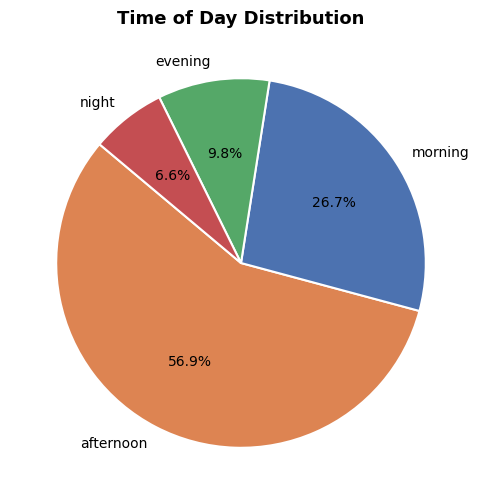

In [19]:
TOD_COLORS = {'morning': '#4C72B0', 'afternoon': '#DD8452', 'evening': '#55A868', 'night': '#C44E52'}
tod_counts = _df['time_of_day'].value_counts()
colors_pie  = [TOD_COLORS[k] for k in tod_counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    tod_counts.values,
    labels=tod_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title('Time of Day Distribution', fontsize=13, fontweight='bold')
plt.show()

This is a tricky part. The vast majority of the `time_of_day` is decided by the model so it could easily be an apriori dataset imbalance. Said that, i also wrote in the prompt that we are reasonably talking abount childrend and so night and evening are not that much frequent while the others are.

/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_83411/979432747.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed  = pd.to_datetime(_df['event_time'], errors='coerce')


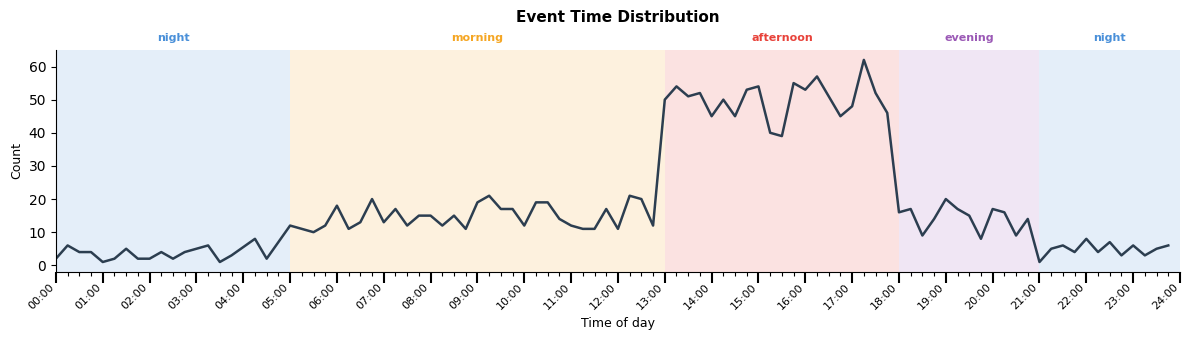

In [20]:
import matplotlib.transforms as mtransforms

_SLOT_RANGES = [
    ("night",     0,   5,  "#4A90D9"),
    ("morning",   5,  13,  "#F5A623"),
    ("afternoon", 13, 18,  "#E8423A"),
    ("evening",   18, 21,  "#9B59B6"),
    ("night",     21, 24,  "#4A90D9"),
]

parsed  = pd.to_datetime(_df['event_time'], errors='coerce')
minutes = parsed.dt.hour * 60 + parsed.dt.minute
counts  = minutes.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(counts.index.values, counts.values, linewidth=1.8, color='#2c3e50')
ax.set_xlim(0, 1440)

# the MM where generated each 15 mins
tick_pos    = np.arange(0, 1441, 15)
tick_labels = [f"{m//60:02d}:00" if m % 60 == 0 else "" for m in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
for tick in ax.xaxis.get_major_ticks():
    is_hour = tick.get_loc() % 60 == 0
    tick.tick1line.set_markersize(8 if is_hour else 3)
    tick.tick1line.set_markeredgewidth(1.5 if is_hour else 0.8)

# times of day colored
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for name, start, end, color in _SLOT_RANGES:
    ax.axvspan(start * 60, end * 60, alpha=0.15, color=color, linewidth=0)
    ax.text((start + end) / 2 * 60, 1.03, name,
            transform=trans, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color, clip_on=False)

ax.set_title('Event Time Distribution', fontsize=11, fontweight='bold', pad=20)
ax.set_xlabel('Time of day', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

The spikes arount 13 and 18 are clearly not realistic and they are caused by the noticeable difference of presence between afternoon and morning and evening. Aside from this, the time distribution is smooth and realistic.

### 4.4 Vocabulary characterizability of the two kind of inputs in different times and normalized per `time_of_day`.

The heatmaps below are built in three stages.

**1. Time binning.** Each event timestamp is converted to minutes from midnight, then snapped to the nearest 30-minute slot (`BIN_MIN = 30`), giving 48 bins spanning the day. Bins with fewer than 20 tokens after preprocessing are dropped (`MIN_BIN_TOKS = 20`) to avoid spurious TF-IDF scores from sparse data.

**2. Text preprocessing (per bin).** For each bin, all caregiver texts are concatenated into a single document. The document is then lowercased, tokenized with a simple `[a-z]+` regex, stripped of English stopwords, filtered to tokens ≥ 3 characters, and lemmatized with WordNet. The result is one bag-of-lemmas string per bin.

**3. TF-IDF + variance ranking.** A `TfidfVectorizer` (top 300 features, sublinear TF) is fit across all valid bins. From the resulting matrix, the 50 words with the highest **inter-bin variance** are selected (`N_TOP = 50`): these are the words whose TF-IDF score changes the most across the day, making them the most temporally discriminative. 

/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_83411/2641588640.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _parsed = pd.to_datetime(_df['event_time'], errors='coerce')


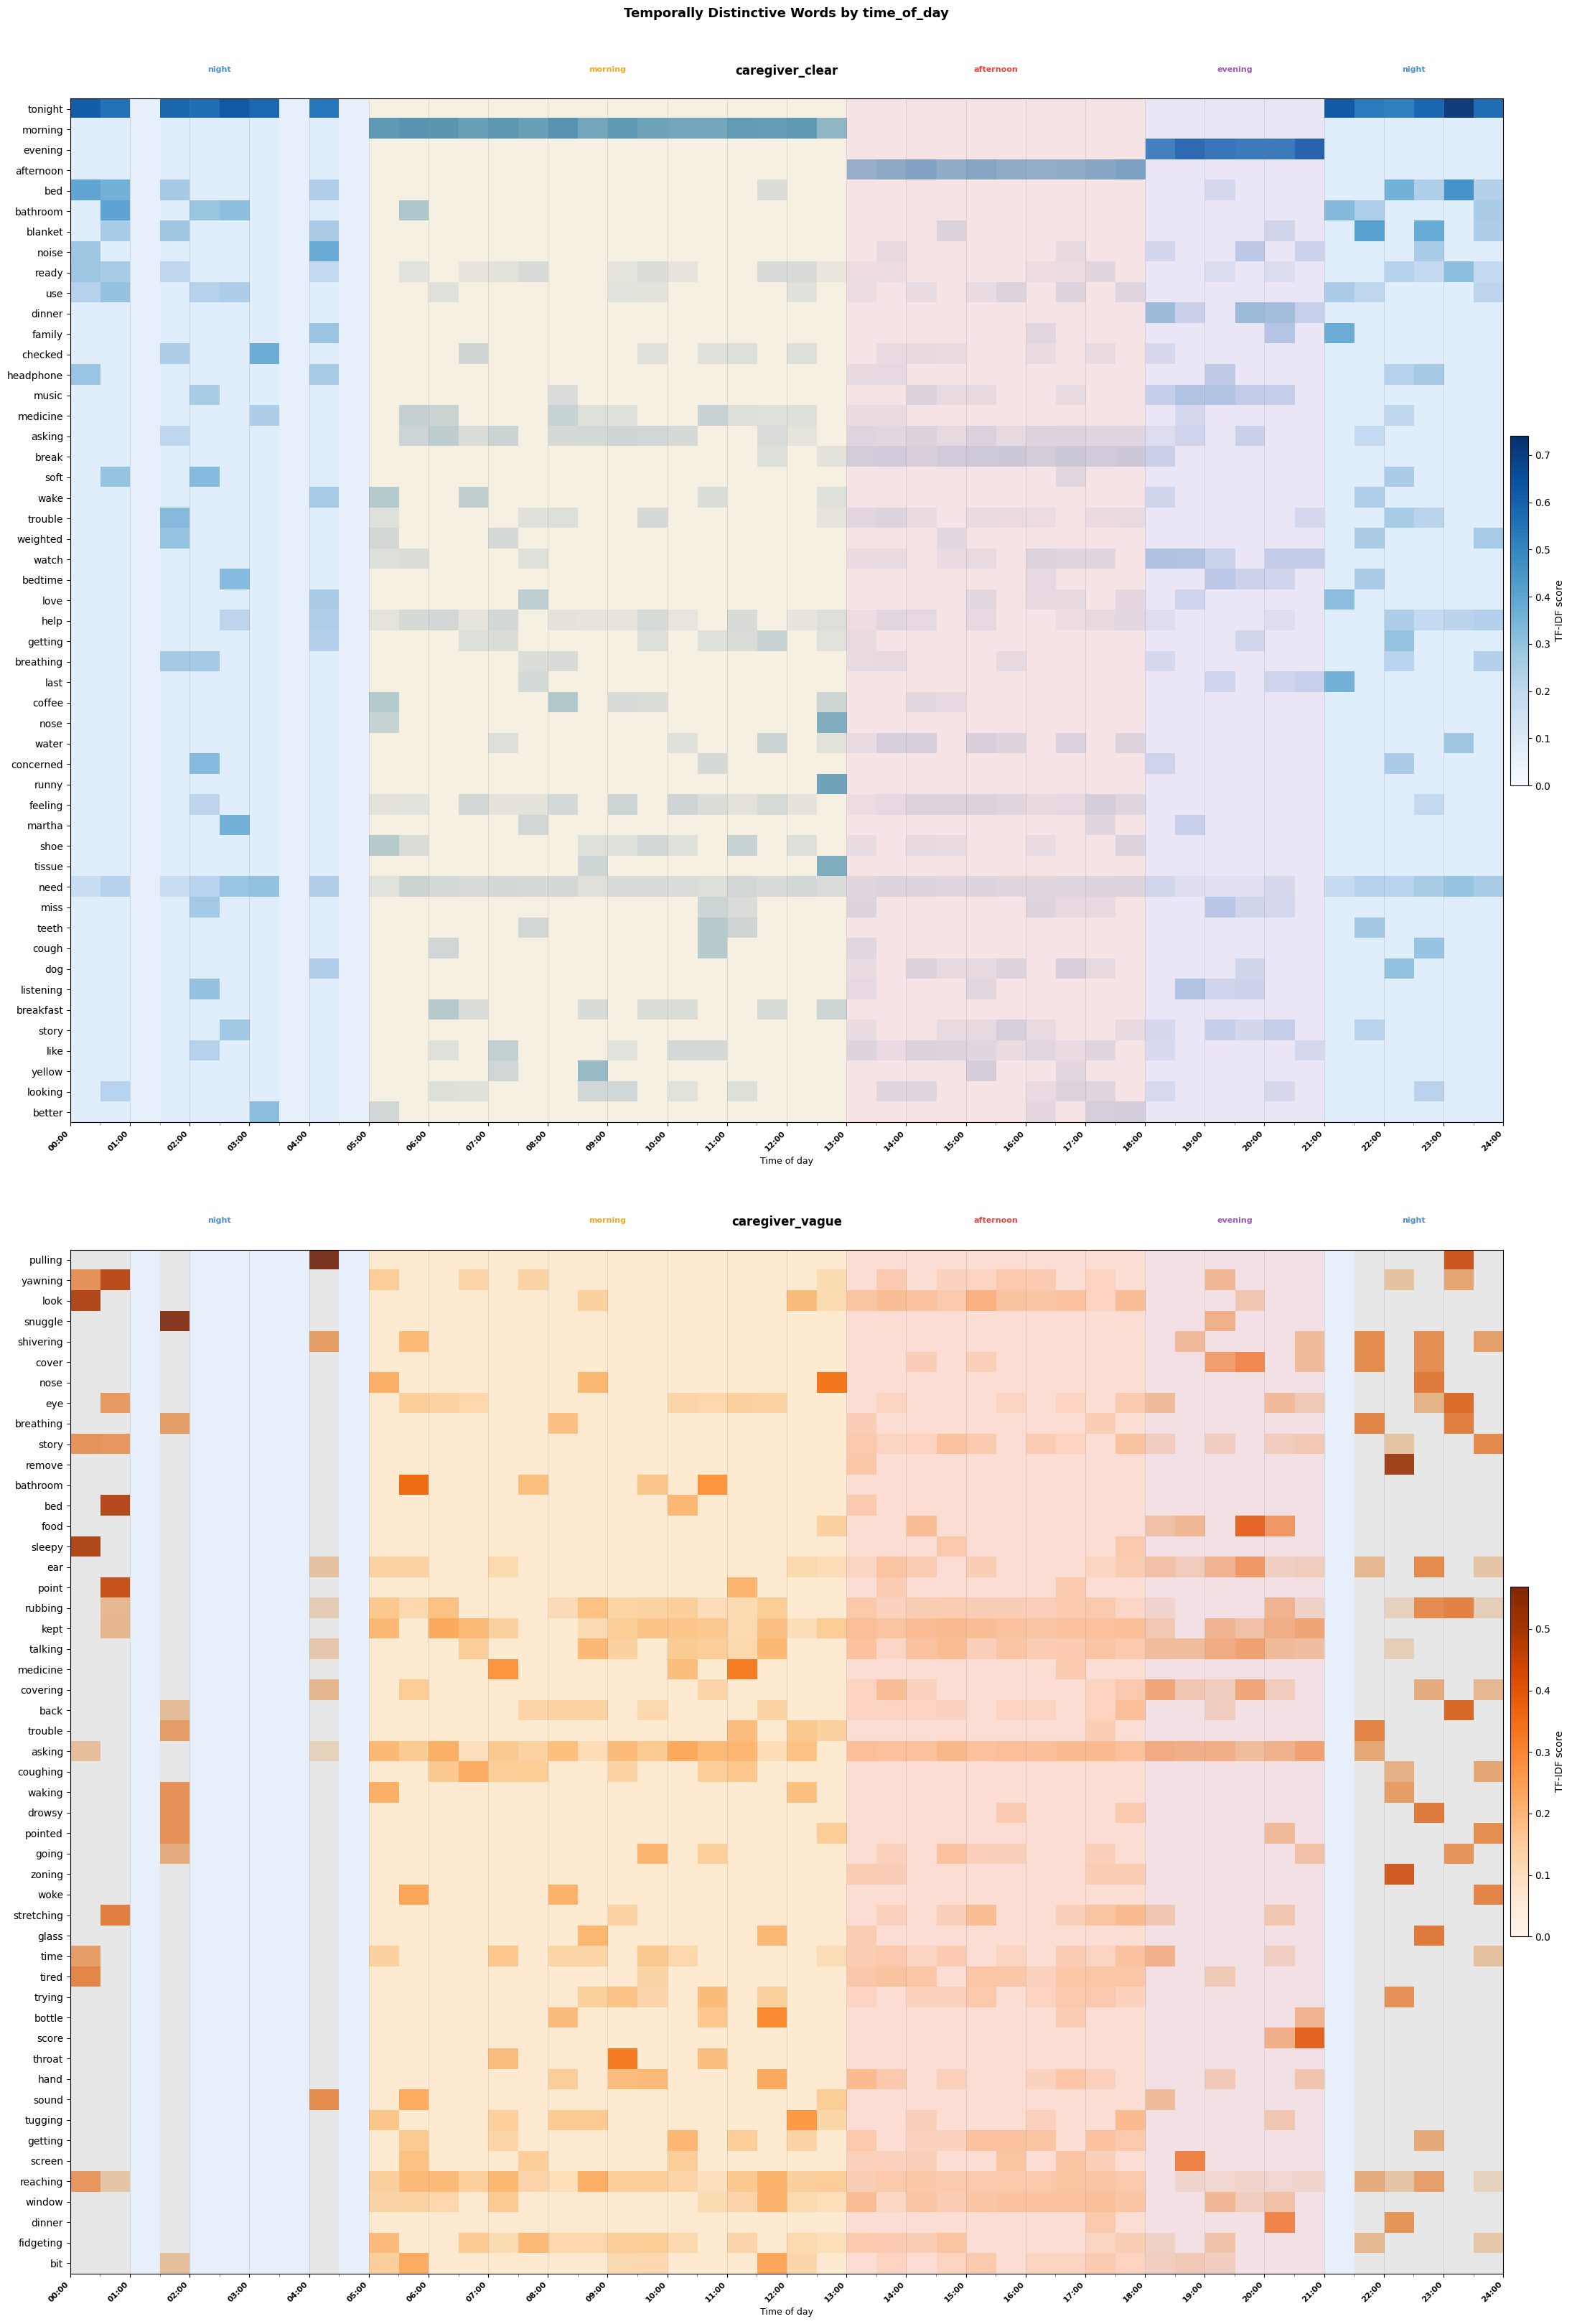

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

_STOPWORDS  = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()
_TOKEN_RE   = re.compile(r'[a-z]+')

def _lemmatize_series(series: pd.Series) -> list[str]:
    out = []
    for text in series.fillna(''):
        tokens = _TOKEN_RE.findall(text.lower())
        lemmas = [
            _lemmatizer.lemmatize(t) for t in tokens
            if t not in _STOPWORDS and len(t) >= 3
        ]
        out.append(' '.join(lemmas))
    return out

BIN_MIN = 30
N_TOP = 50
MIN_BIN_TOKS = 20

_parsed = pd.to_datetime(_df['event_time'], errors='coerce')
_df['_min'] = _parsed.dt.hour * 60 + _parsed.dt.minute
_df['_bin'] = (_df['_min'] // BIN_MIN) * BIN_MIN
time_bins = list(range(0, 1440, BIN_MIN))

def _tfidf_matrix(col: str):
    bin_texts, bin_counts = {}, {}
    for b in time_bins:
        sub = _df.loc[_df['_bin'] == b, col]
        joined = ' '.join(sub.fillna('').tolist())
        lemmatized = _lemmatize_series(pd.Series([joined]))[0]
        bin_texts[b] = lemmatized
        bin_counts[b] = len(lemmatized.split())

    valid_bins = [b for b in time_bins if bin_counts[b] >= MIN_BIN_TOKS]
    docs = [bin_texts[b] for b in valid_bins]

    vec   = TfidfVectorizer(max_features=300, sublinear_tf=True)
    tfidf = vec.fit_transform(docs).toarray()
    vocab = np.array(vec.get_feature_names_out())

    # top N_TOP words by inter-bin variance
    top_idx   = np.argsort(tfidf.var(axis=0))[::-1][:N_TOP]
    top_words = vocab[top_idx].tolist()
    mat       = tfidf[:, top_idx]

    full_mat = np.full((len(time_bins), N_TOP), np.nan)
    for i, b in enumerate(valid_bins):
        full_mat[time_bins.index(b)] = mat[i]

    return full_mat, top_words

mat_clear, words_clear = _tfidf_matrix('caregiver_clear')
mat_vague, words_vague = _tfidf_matrix('caregiver_vague')

def _add_tod_bands(ax):
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    for name, h_start, h_end, color in _SLOT_RANGES:
        ax.axvspan(h_start * 60, h_end * 60, alpha=0.13, color=color, linewidth=0, zorder=0)
        ax.text(
            (h_start + h_end) / 2 * 60, 1.025, name,
            transform=trans, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color, clip_on=False,
        )

configs = [
    (mat_clear, words_clear, 'Blues',   'caregiver_clear'),
    (mat_vague, words_vague, 'Oranges', 'caregiver_vague'),
]

fig, axes = plt.subplots(2, 1, figsize=(22, 32))

for ax, (mat, words, cmap, title) in zip(axes, configs):
    n  = len(words)
    im = ax.imshow(
        mat.T,
        aspect='auto',
        cmap=cmap,
        interpolation='nearest',
        extent=[0, 1440, n - 0.5, -0.5],
    )
    ax.set_xlim(0, 1440)
    ax.set_xticks(range(0, 1441, 60))
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(25)],
        rotation=45, ha='right', fontsize=8, fontweight='bold',
    )
    ax.set_xticks(range(0, 1441, BIN_MIN), minor=True)
    ax.tick_params(axis='x', which='minor', length=3, width=0.6, color='grey')
    ax.set_yticks(range(n))
    ax.set_yticklabels(words, fontsize=10)
    for h in range(25):
        ax.axvline(h * 60, color='grey', linewidth=0.4, alpha=0.4, zorder=1)
    _add_tod_bands(ax)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=24)
    ax.set_xlabel('Time of day', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.012, pad=0.005, label='TF-IDF score')

plt.suptitle(
    'Temporally Distinctive Words by time_of_day',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout(h_pad=5)
plt.show()

_df.drop(columns=['_min', '_bin'], inplace=True)

Here comes the interesting part, in those plots we inspect how much the words characterize the times of day and hours. In this sense the idea is to understand the semantic quality of the annotation and its potential usefulness for the downstream task. The more the words are specific to a time of day or hour, the more they are informative and useful for the downstream task.

So we can notice:
- `caregiver_clear`:
    1. shows sharp, well-localised patterns that align almost perfectly with the TOD bands.
    2. *bed* and *bathroom* peak in the 00:00–04:00 night slot
    3. *breakfast* and *coffee* concentrate in the 06:00–09:00 morning window
    4. *dinner* and *medicine* appear predominantly in the afternoon–evening transition (14:00–20:00) 
    5. *bedtime* re-emerges after 21:00. 

    The pattern is sparse but coherent and most of the cells are empty, meaning that the words are very specific to a time of day and thus very informative for the downstream task.

- `caregiver_vague`:
    1. shows a much noiser pattern which is coherent with its idea of being vague and thus less informative for the downstream task.
    2. we clearly see higher isolated peaks (that are not so clearly characteristic) and more homogeous lines that also overcome the time of day bands, mining the informativeness of the words.

### 4.5 Which is the relation between the sentence and the inputs?

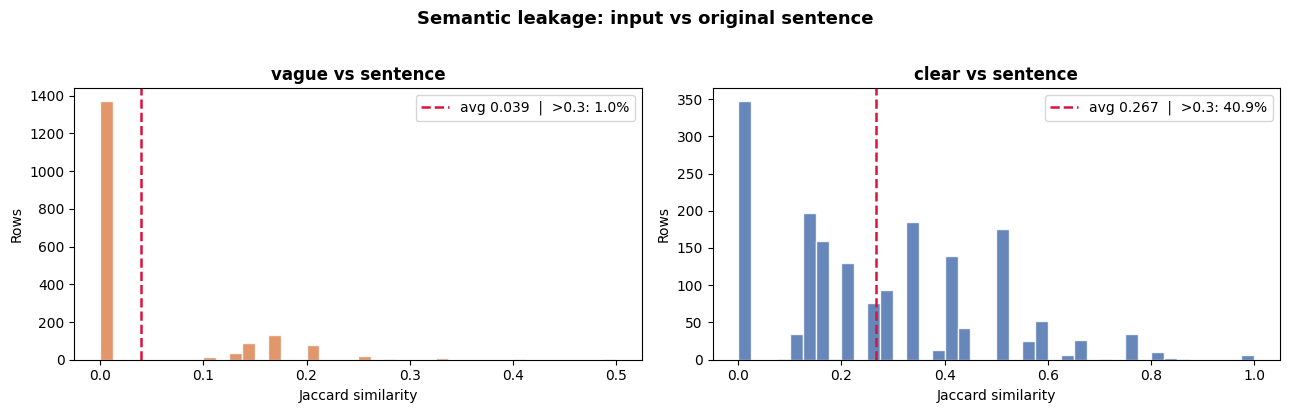


  vague [Jaccard == 1.0]  (0 total rows)


,sentence,caregiver_vague,jaccard_vague_sentence



  vague [Jaccard == 0.0]  (1371 total rows)


,sentence,caregiver_vague,jaccard_vague_sentence
1,The music is too loud in here.,he keeps covering his ears,0.0
3,My shirt feels scratchy on my neck.,he keeps pulling at his collar,0.0
4,The fan is spinning round and round.,he keeps running to it,0.0
5,I like the crunchy crackers.,he keeps reaching for the snacks,0.0
7,The sandbox is cold today.,he keeps looking out the window,0.0



  clear [Jaccard == 1.0]  (7 total rows)


,sentence,caregiver_clear,jaccard_clear_sentence
73,I am ready for the morning song.,He is ready for his morning song at 07:30 this...,1.0
643,I am feeling very blue this morning.,He is feeling very blue at 09:15 this morning,1.0
672,I am feeling a bit down this morning.,He is feeling a bit down at 10:15 this morning,1.0
871,I am feeling a bit lonely this morning.,He is feeling a bit lonely at 10:30 this morning,1.0
1210,We went to the beach last summer.,They went to the beach last summer at 07:30.,1.0



  clear [Jaccard == 0.0]  (347 total rows)


,sentence,caregiver_clear,jaccard_clear_sentence
3,My shirt feels scratchy on my neck.,He needs help with his pyjamas at 04:15 tonight,0.0
9,My hands are very sticky.,He wants a bath at 16:00 this afternoon,0.0
14,The water in the sink is cold.,He wants to brush his teeth at 10:45 this morning,0.0
15,My blue train is under the chair.,He is playing with his trains at 14:45 this af...,0.0
22,The slide is too hot for my legs.,He wants to cool off at 15:00 this afternoon,0.0


In [22]:
# Those were already defined with other variables but for better readibility i try to keep the cells autodefined
_STOP = set(stopwords.words('english'))
_TOKEN = re.compile(r'[a-z]+')

def _tokens(text: str) -> set:
    if not isinstance(text, str): return set()
    return {t for t in _TOKEN.findall(text.lower()) if t not in _STOP and len(t) >= 3}

def jaccard(a: str, b: str) -> float:
    ta, tb = _tokens(a), _tokens(b)
    if not ta or not tb: return 0.0
    return len(ta & tb) / len(ta | tb)

_df['jaccard_vague_sentence'] = _df.apply(
    lambda r: jaccard(r['caregiver_vague'], r['sentence']), axis=1)
_df['jaccard_clear_sentence'] = _df.apply(
    lambda r: jaccard(r['caregiver_clear'], r['sentence']), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color, label in [
    (axes[0], 'jaccard_vague_sentence',  '#DD8452', 'vague vs sentence'),
    (axes[1], 'jaccard_clear_sentence',  '#4C72B0', 'clear vs sentence'),
]:
    vals = _df[col]
    ax.hist(vals, bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(vals.mean(), color='crimson', lw=1.8, ls='--',
               label=f'avg {vals.mean():.3f}  |  >0.3: {(vals>0.3).mean()*100:.1f}%')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Jaccard similarity')
    ax.set_ylabel('Rows')
    ax.legend()

plt.suptitle('Semantic leakage: input vs original sentence', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for col, label in [
    ('jaccard_vague_sentence', 'vague'),
    ('jaccard_clear_sentence', 'clear'),
]:
    cols_show = ['sentence', 'caregiver_vague' if 'vague' in col else 'caregiver_clear', col]
    
    exact = _df[_df[col] == 1.0][cols_show].head(5)
    zero  = _df[_df[col] == 0.0][cols_show].head(5)
    
    print(f"\n{'='*60}")
    print(f"  {label} [Jaccard == 1.0]  ({(_df[col]==1.0).sum()} total rows)")
    display(exact)
    print(f"\n  {label} [Jaccard == 0.0]  ({(_df[col]==0.0).sum()} total rows)")
    display(zero)

The fact that the vast majority of them has jaccard equal to 0 means that the sentence is not a copy of the inputs and thus it is not a simple concatenation of them. This is a good sign as it means that the model has actually processed the inputs and produced an output that is not just a copy of them. This could also mean that the model made up the inputs but the partial inputs and seems to be enouranging.

The fact that the `caregiver_clear` has much more intermediate values od jaccard is very good since it has to recall the input information.

The same with the opposite situation for `caregiver_vague`.

### 4.6 How much `schedule` is well formed?

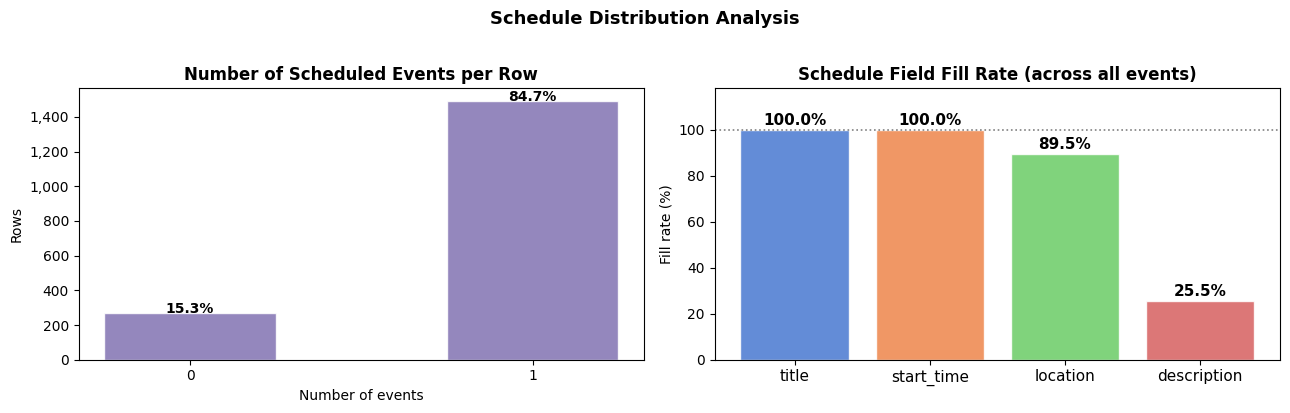

In [23]:
_df['n_events'] = _df['schedule'].apply(lambda s: len(s) if s is not None else 0)
nev_counts = _df['n_events'].value_counts().sort_index()
all_events = [ev for sched in _df['schedule'] if sched is not None for ev in sched]
fields     = ['title', 'start_time', 'location', 'description']
fill_rates = {f: sum(1 for ev in all_events if ev.get(f) is not None) / len(all_events) * 100
              for f in fields}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# n_events distribution
bars0 = axes[0].bar(nev_counts.index.astype(str), nev_counts.values,
                    color='#8172B2', alpha=0.85, edgecolor='white', width=0.5)
for bar, (k, v) in zip(bars0, nev_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{v/len(_df)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Number of Scheduled Events per Row', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of events')
axes[0].set_ylabel('Rows')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# fill-rate fields
field_colors = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']
bars1 = axes[1].bar(fill_rates.keys(), fill_rates.values(),
                    color=field_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, fill_rates.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Schedule Field Fill Rate (across all events)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fill rate (%)')
axes[1].set_ylim(0, 118)
axes[1].axhline(100, color='grey', linestyle=':', linewidth=1.2)
axes[1].tick_params(axis='x', labelsize=11)

plt.suptitle('Schedule Distribution Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This is good even if i had to force it in the prompt, the sentences are not written for the task of this project. At least in this way we can ensure the information injection via tools.

I add the distractors in order to see if the model is able to ignore them by actually looking at the time of the event. I have to do in this way since it is way more difficult to control this via prompts.

In [24]:
RNG_SEED = 42
rng = random.Random(RNG_SEED)

COLOR_REAL       = "#2a7ab5"
COLOR_DISTRACTOR = "#b8b8b8"
COLOR_EMPTY      = "#d94f3d"

DISTRACTOR_POOL = [
    # Therapies
    {"title": "Speech therapy session",      "location": "therapy centre",   "description": None},
    {"title": "Occupational therapy",        "location": "therapy centre",   "description": "fine motor skills"},
    {"title": "Physiotherapy",               "location": "rehab centre",     "description": None},
    {"title": "Music therapy",               "location": "therapy room",     "description": None},
    {"title": "Art therapy",                 "location": "therapy room",     "description": None},
    {"title": "Hydrotherapy",                "location": "pool",             "description": None},
    {"title": "Equine therapy",              "location": "riding centre",    "description": None},
    {"title": "Sensory integration session", "location": "therapy centre",   "description": None},
    {"title": "Cognitive rehabilitation",    "location": "therapy centre",   "description": None},
    {"title": "AAC device training",         "location": "therapy centre",   "description": "with speech therapist"},
    # Medical appointments
    {"title": "Pediatrician visit",          "location": "clinic",           "description": "routine check-up"},
    {"title": "Neurologist appointment",     "location": "hospital",         "description": None},
    {"title": "Audiologist check",           "location": "hospital",         "description": "hearing test"},
    {"title": "Ophthalmologist visit",       "location": "eye clinic",       "description": None},
    {"title": "Dietitian appointment",       "location": "clinic",           "description": None},
    # School
    {"title": "School bus pickup",           "location": "home",             "description": None},
    {"title": "Classroom reading session",   "location": "school",           "description": None},
    {"title": "Lunch at school",             "location": "school canteen",   "description": None},
    {"title": "Support teacher session",     "location": "school",           "description": "individual support"},
    {"title": "After-school care",           "location": "school",           "description": None},
    # Routine care
    {"title": "Medication administration",   "location": "home",             "description": "morning meds"},
    {"title": "Personal care routine",       "location": "home",             "description": "bath and dressing"},
    {"title": "Caregiver home visit",        "location": "home",             "description": None},
    {"title": "Meal prep with caregiver",    "location": "home",             "description": None},
    # Social / recreational
    {"title": "Adaptive swimming lesson",    "location": "sports centre",    "description": None},
    {"title": "Park walk with caregiver",    "location": "local park",       "description": None},
    {"title": "Playdate",                    "location": "community centre", "description": None},
    {"title": "Family lunch",                "location": "home",             "description": None},
    {"title": "Inclusive sports activity",   "location": "sports centre",    "description": None},
    {"title": "Library storytime",           "location": "public library",   "description": None},
]

# Offset pool: ±[4h00–5h00] in 15-min steps — guarantees the distractor falls
# outside any reasonable narrow time-window filter around event_time
_OFFSETS_MIN = [h * 60 + m for h in range(4, 6) for m in (0, 15, 30, 45)]


def _distractor_time(event_time_str: str) -> str:
    """Returns a start_time offset by ±[4h, 5h] from event_time, with 24h wrap."""
    base  = datetime.strptime(event_time_str, "%H:%M")
    sign  = rng.choice([-1, 1])
    delta = sign * int(rng.choice(_OFFSETS_MIN))
    h, m  = divmod((base.hour * 60 + base.minute + delta) % (24 * 60), 60)
    return f"{h:02d}:{m:02d}"


def _add_distractor(row):
    template   = rng.choice(DISTRACTOR_POOL)
    distractor = {
        "title":       template["title"],
        "start_time":  _distractor_time(row["event_time"]),
        "location":    template["location"],
        "description": template["description"],
    }
    return list(row["schedule"]) + [distractor]


df_ann["schedule"] = df_ann.apply(_add_distractor, axis=1)

# Refresh _df so subsequent analysis cells see the updated schedule
_df = df_ann.copy()

### 4.7 Are there any duplicates in the input? 

#### 4.7.1 Look at the duplicates

In [25]:
num_duplicates_clear = _df['caregiver_clear'].duplicated().sum()
num_duplicates_vague = _df['caregiver_vague'].duplicated().sum()
print(f"Duplicates: {num_duplicates_clear} in caregiver_clear, {num_duplicates_vague} in caregiver_vague")

Duplicates: 23 in caregiver_clear, 382 in caregiver_vague


This still makes sense, the more genereal it is and the more likely to say the same things in different situations.

In [26]:
_df[_df['caregiver_clear'].duplicated()]['caregiver_clear'].value_counts()[:20]

caregiver_clear
He needs a tissue for his runny nose at 12:30 this morning           3
He wants to listen to music with headphones at 19:00 this evening    1
He needs to go to the bathroom at 05:30 this morning                 1
He wants to go to the sensory room at 14:15 this afternoon           1
He needs a break in the quiet corner at 17:45 this afternoon         1
He needs more paper for his drawing at 10:15 this morning            1
He needs help with his pyjamas at 04:15 tonight                      1
He needs help with his shoes at 09:45 this morning                   1
He needs to use the bathroom at 00:30 tonight                        1
He needs his humidifier at 06:45 this morning                        1
She is stretching her fingers at 16:00 this afternoon                1
He is ready for bed at 23:00 tonight                                 1
He is annoyed by the noise at 19:30 this evening                     1
He needs to sit down at 16:15 this afternoon                 

All couples in practice, not a real problem.

In [27]:
_df[_df['caregiver_vague'].duplicated()]['caregiver_vague'].value_counts()[:20]

caregiver_vague
he keeps looking out the window           36
he keeps asking for it again              18
he keeps covering his ears                16
he keeps reaching for it                  16
he keeps checking the clock               15
he keeps rubbing his eyes                  9
he keeps fidgeting in his seat             8
he keeps reaching for the fridge           6
he keeps sniffing the air                  5
he keeps asking to go out                  5
he keeps tilting his head back             5
he keeps asking questions                  5
he keeps reaching for the toy box          4
he keeps raising his hand                  4
he keeps reaching for the tablet           4
he keeps asking to go outside              4
he keeps looking at the clock              4
he keeps reaching for the toy              3
he keeps reaching for the art supplies     3
he keeps hiding behind me                  3
Name: count, dtype: int64

They seem reasonable duplicates, applicable in various domestic and more specific situations. 

A good idea is to better inspect the top 6 that clearly more impactful than others.

#### 4.7.2 Understand the most common duplicates in `caregiver_vague`.

For each of the top-6 most duplicated vague texts, the code:

1. **Splits schedule events into real vs distractor.** For every row in the group, it walks the `schedule` list and classifies each event as **real** if its `start_time` matches the row's `event_time` (the event that was actually happening), and **distractor** otherwise. This distinction matters because a model shown the schedule must identify the real event among the distractors.

2. **Aggregates title frequencies.** All real and distractor titles across the group are counted separately, then merged into a combined ranking sorted by total occurrences.

3. **Plots a stacked horizontal bar chart** for each vague text, with the subtitle reporting how many rows had no real event at all.

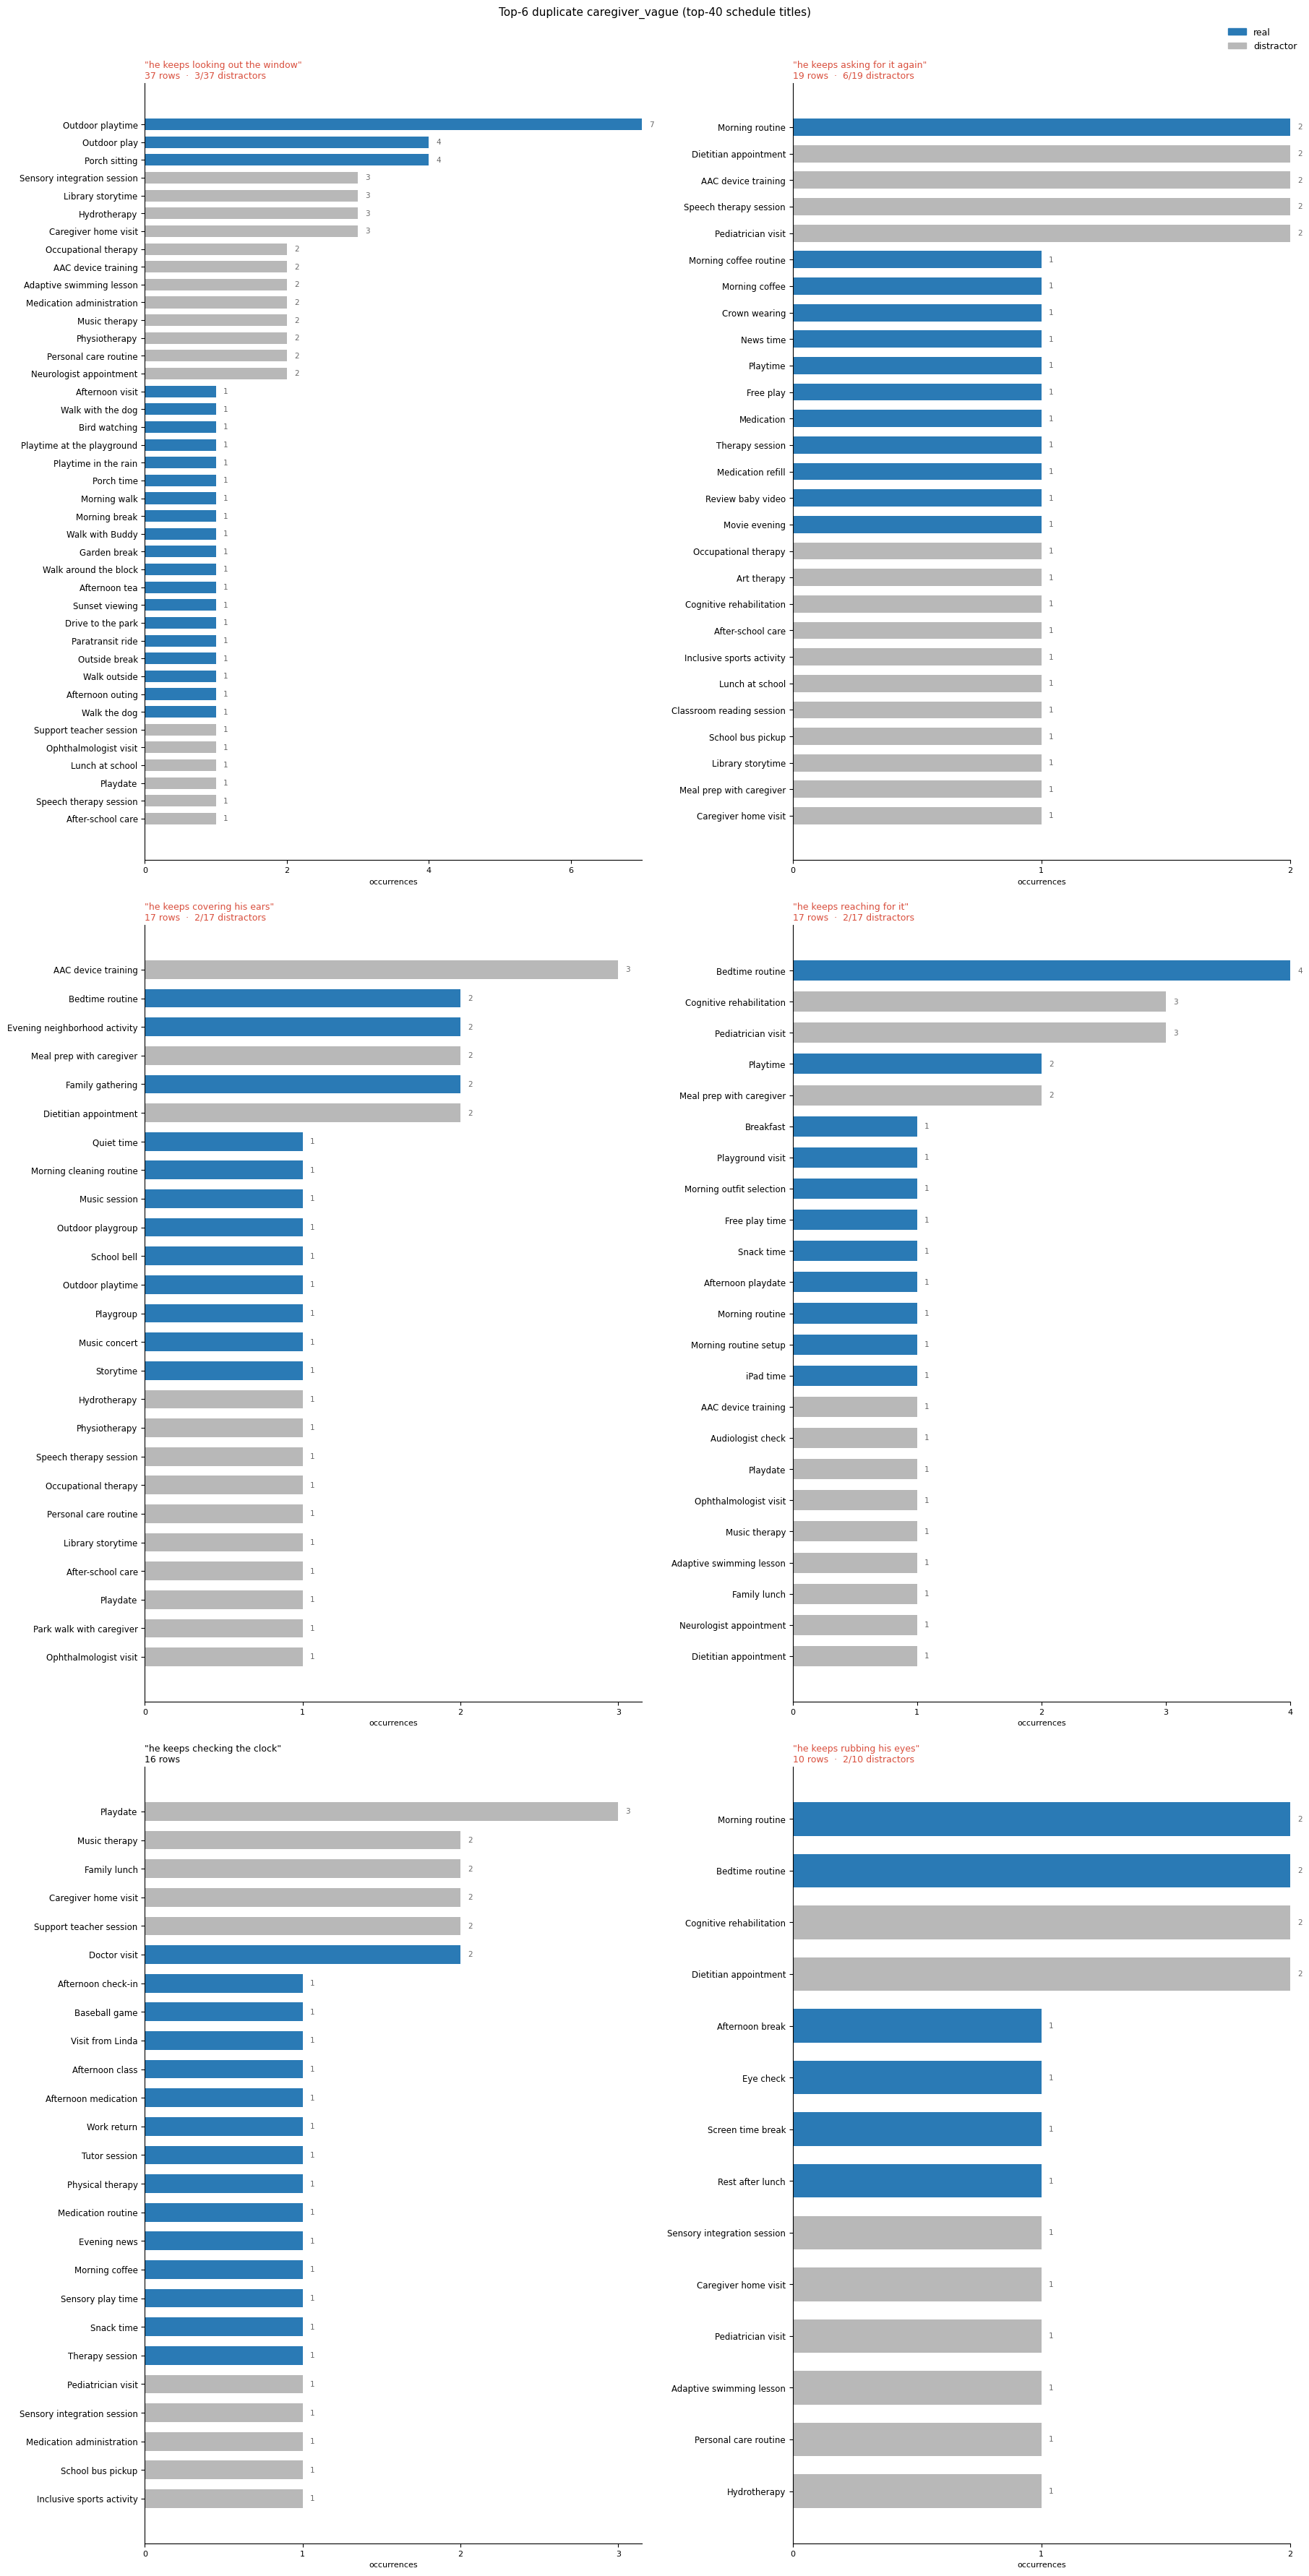

In [28]:
# A schedule event is "real"       if start_time == row event_time
# A schedule event is "distractor" if start_time != row event_time

TOP_N_VAGUE  = 6
TOP_K_TITLES = 40


def _split_titles(schedule_list, event_time: str):
    real, distractor = [], []
    if not isinstance(schedule_list, list):
        return real, distractor
    for ev in schedule_list:
        if not (isinstance(ev, dict) and "title" in ev and "start_time" in ev):
            continue
        (real if ev["start_time"] == event_time else distractor).append(ev["title"])
    return real, distractor


vague_counts = _df["caregiver_vague"].value_counts()
top_dupes    = vague_counts[vague_counts > 1].head(TOP_N_VAGUE)

panels = []
for vague_text, total_rows in top_dupes.items():
    group = _df[_df["caregiver_vague"] == vague_text]
    real_all, dist_all, no_real = [], [], 0
    for _, row in group.iterrows():
        r, d = _split_titles(row["schedule"], row["event_time"])
        if not r:
            no_real += 1
        real_all.extend(r)
        dist_all.extend(d)

    real_counts = pd.Series(real_all).value_counts()
    dist_counts = pd.Series(dist_all).value_counts()

    combined = (
        pd.concat([real_counts.rename("real"), dist_counts.rename("dist")], axis=1)
        .fillna(0).astype(int)
        .assign(total=lambda d: d["real"] + d["dist"])
        .sort_values("total", ascending=False)
        .head(TOP_K_TITLES)
    )
    panels.append((vague_text, total_rows, no_real, combined))

N_COLS = 2
N_ROWS = math.ceil(TOP_N_VAGUE / N_COLS)
ROW_H  = max(2.5, TOP_K_TITLES * 0.28)  # panel height scales with TOP_K

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, N_ROWS * ROW_H + 1.2), constrained_layout=True)
axes = axes.flatten()

# hide surplus axes if TOP_N_VAGUE is odd
for ax in axes[len(panels):]:
    ax.set_visible(False)

for ax, (vague_text, total_rows, no_real, combined) in zip(axes, panels):
    y      = range(len(combined))
    labels = [t if len(t) <= 34 else t[:32] + "\u2026" for t in combined.index]

    ax.barh(y, combined["real"], color=COLOR_REAL, height=0.65, label="real")
    ax.barh(y, combined["dist"], left=combined["real"], color=COLOR_DISTRACTOR, height=0.65, label="distractor")

    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.invert_yaxis()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=4))
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("occurrences", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # inline totals
    max_total = combined["total"].max()
    for i, tot in enumerate(combined["total"]):
        ax.text(tot + max_total * 0.015, i, str(tot),
                va="center", ha="left", fontsize=7.5, color="dimgray")

    # panel title
    short = f'"{vague_text}"' if len(vague_text) <= 36 else f'"{vague_text[:34]}\u2026"'
    no_real_str = f"  \u00b7  {no_real}/{total_rows} distractors" if no_real > 0 else ""
    ax.set_title(
        f"{short}\n{total_rows} rows{no_real_str}",
        fontsize=9, loc="left", pad=5,
        color=COLOR_EMPTY if no_real > 0 else "black",
    )

legend_patches = [
    mpatches.Patch(color=COLOR_REAL,       label="real"),
    mpatches.Patch(color=COLOR_DISTRACTOR, label="distractor"),
]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9, frameon=False, bbox_to_anchor=(1.0, 1.015))
fig.suptitle(
    f"Top-{TOP_N_VAGUE} duplicate caregiver_vague (top-{TOP_K_TITLES} schedule titles)",
    fontsize=11, y=1.02,
)
plt.show()

In general the duplicates are well populated with various schedule events, both real (most important) and distractor, which is a good sign as it means that they are not just repeated in the same context but they are actually used in different contexts. This is a good sign for the quality of the annotation and its potential usefulness for the downstream task. The agent so could effectivelt disambiguate the vague behaviour by looking at the schedule and understanding which is the real event among the distractors.

# 5. Save final eval dataset

In [29]:
EVAL_FINAL_PATH = ANN_DIR / 'eval_final.parquet'
df_ann.to_parquet(EVAL_FINAL_PATH, index=False)

print(f'Saved : {EVAL_FINAL_PATH}')
print(f'Rows  : {len(df_ann):,}')
print(f'Cols  : {list(df_ann.columns)}')
print()
print('Schedule spot-check (first 3 rows):')
for i, row in df_ann.head(3).iterrows():
    print(f"  row {i}: {row['sentence']!r}")
    for ev in row['schedule']:
        print(f"    {ev}")

Saved : /Users/pelle/Development/GitHub/aac-mcp-agent/annotation/eval_final.parquet
Rows  : 1,760
Cols  : ['sentence', 'concepts', 'caregiver_clear', 'caregiver_vague', 'time_of_day', 'event_time', 'schedule', 'tod_selection', 'split']

Schedule spot-check (first 3 rows):
  row 0: 'The blue train is going fast.'
    {'title': 'Medication administration', 'start_time': '02:15', 'location': 'home', 'description': 'morning meds'}
  row 1: 'The music is too loud in here.'
    {'title': 'Family gathering', 'start_time': '20:15', 'location': None, 'description': None}
    {'title': 'Meal prep with caregiver', 'start_time': '01:00', 'location': 'home', 'description': None}
  row 2: 'Look at the bubbles popping.'
    {'title': 'Playtime with bubbles', 'start_time': '17:15', 'location': None, 'description': None}
    {'title': 'Sensory integration session', 'start_time': '13:00', 'location': 'therapy centre', 'description': None}
